In [1]:
import MDAnalysis as mda
import MDAnalysisTests

import numpy as np

/Users/hjaeger/repos/mdanalysis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
test_sizes = np.array([10,100,1000,10000,100000])


In [3]:
universes = {}
for n in test_sizes:
    n_residues = n
    n_atoms = 3 * n_residues
    n_segments = 1

    universes[n] = MDAnalysisTests.dummy.make_Universe(extras=('masses',), size=(n_atoms, n_residues, n_segments), trajectory=True)
    universes[n].atoms.positions = np.random.rand(n_atoms, 3) * 10.0  # large box to ensure wrapping is needed
    universes[n].dimensions = np.array([10.0, 10.0, 10.0, 90.0, 90.0, 90.0])

In [ ]:
# Benchmark the wrap method for all test sizes
times = []
for n in test_sizes:
    u = universes[n]
    time = %timeit -o u.atoms.wrap(compound="residues", center="com", inplace=False)
    times.append(time.average)
times = np.array(times)
#np.savetxt("old_wrap_benchmark_times.txt", np.column_stack((test_sizes, times)), header="Num_Compounds Time_s")

36.1 μs ± 391 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
54.2 μs ± 81.9 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
229 μs ± 1.58 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.94 ms ± 11.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
19 ms ± 167 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


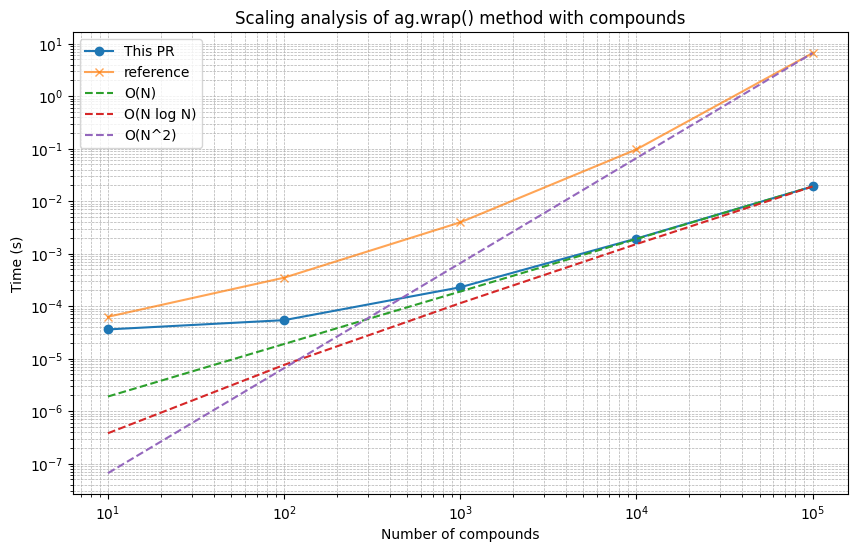

In [19]:
import matplotlib.pyplot as plt

old = np.loadtxt("old_wrap_benchmark_times.txt", skiprows=1)

# Plot the scaling behavior
plt.figure(figsize=(10, 6))
plt.plot(test_sizes, times, marker='o', label='This PR')
plt.plot(old[:,0], old[:,1], marker='x', label='reference', alpha=0.7)


# Add O(N) and O(N log N) reference lines
n_ref = np.array(test_sizes)
o_n = times[-1] * (n_ref / test_sizes[-1])  # Scale O(N) line
plt.plot(n_ref, o_n, linestyle='--', label='O(N)')

o_nlogn = times[-1] * (n_ref * np.log(n_ref) / (test_sizes[-1] * np.log(test_sizes[-1])))  # Scale O(N log N) line
plt.plot(n_ref, o_nlogn, linestyle='--', label='O(N log N)')

o_n2 = old[-1,1] * (n_ref**2 / old[-1,0]**2)  # Scale O(N^2) line
plt.plot(n_ref, o_n2, linestyle='--', label='O(N^2)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of compounds')
plt.ylabel('Time (s)')
plt.title('Scaling analysis of ag.wrap() method with compounds')
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()